# Data Visualization - Assignment 4
## Theme: Organizational Structure & Global Connectivity

**Student ID:** A4_2023xxx &nbsp;|&nbsp; **Date:** April 2026

---

### Story
Two datasets are visualized under one theme:
- **HR Dataset** - Internal company hierarchy (Company > Department > Position > Employee)
- **Routes Dataset** - Global airline route network (directed graph)

### Design System (Dark Monochromatic)

| Token | Value |
|---|---|
| Background | `#0B0F1A` |
| Surface | `#111827` |
| Primary | `#1E3A8A` |
| Secondary | `#0EA5A4` |
| Accent | `#22D3EE` |
| Text Primary | `#E5E7EB` |
| Text Secondary | `#9CA3AF` |

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import plotly.graph_objects as go
import plotly.io as pio
import scipy.cluster.hierarchy as sch
import os

BG        = '#0B0F1A'
SURFACE   = '#111827'
PRIMARY   = '#1E3A8A'
SECONDARY = '#0EA5A4'
ACCENT    = '#22D3EE'
TEXT_PRI  = '#E5E7EB'
TEXT_SEC  = '#9CA3AF'

matplotlib.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': SURFACE,
    'axes.edgecolor': TEXT_SEC, 'axes.labelcolor': TEXT_PRI,
    'xtick.color': TEXT_SEC, 'ytick.color': TEXT_SEC,
    'text.color': TEXT_PRI, 'grid.color': '#1F2937',
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'legend.facecolor': SURFACE, 'legend.edgecolor': TEXT_SEC,
})
pio.templates.default = 'plotly_dark'
os.makedirs('visualizations', exist_ok=True)
print('Setup complete - all libraries loaded.')

Setup complete - all libraries loaded.


---
## Dataset 1: HR Dataset (HRDataset_v14.csv)

**Hierarchy structure:** Company > Department > Position > Employee

| Column | Role |
|---|---|
| `Department` | Hierarchy level 2 |
| `Position` | Hierarchy level 3 |
| `Employee_Name` | Leaf nodes |
| `Salary` | Node size / colour |
| `EmpSatisfaction` | Clustering feature |

In [2]:
hr = pd.read_csv('HRDataset_v14.csv')
hr.columns = hr.columns.str.strip()
hr['Department']    = hr['Department'].str.strip()
hr['Position']      = hr['Position'].str.strip()
hr['Employee_Name'] = hr['Employee_Name'].str.strip()
print('Shape:', hr.shape)
print('Departments:', hr['Department'].nunique(), list(hr['Department'].unique()))
print('Positions:', hr['Position'].nunique())
hr[['Employee_Name','Department','Position','Salary','PerformanceScore']].head(5)

Shape: (311, 36)
Departments: 6 ['Production', 'IT/IS', 'Software Engineering', 'Admin Offices', 'Sales', 'Executive Office']
Positions: 31


,Employee_Name,Department,Position,Salary,PerformanceScore
0,"Adinolfi, Wilson K",Production,Production Technician I,62506,Exceeds
1,"Ait Sidi, Karthikeyan",IT/IS,Sr. DBA,104437,Fully Meets
2,"Akinkuolie, Sarah",Production,Production Technician II,64955,Fully Meets
3,"Alagbe,Trina",Production,Production Technician I,64991,Fully Meets
4,"Anderson, Carol",Production,Production Technician I,50825,Fully Meets


In [3]:
grp = (hr.groupby(['Department','Position'])
         .agg(EmployeeCount=('Employee_Name','count'), AvgSalary=('Salary','mean'))
         .reset_index())
records = []
records.append(dict(id='Company', parent='', label='Company',
                    value=len(hr), avg_salary=hr['Salary'].mean()))
for dept in hr['Department'].unique():
    dd = hr[hr['Department']==dept]
    records.append(dict(id=dept, parent='Company', label=dept,
                        value=len(dd), avg_salary=dd['Salary'].mean()))
for _, row in grp.iterrows():
    pid = str(row['Department']) + '|' + str(row['Position'])
    records.append(dict(id=pid, parent=row['Department'], label=row['Position'],
                        value=row['EmployeeCount'], avg_salary=row['AvgSalary']))
hier_df = pd.DataFrame(records)
print('Hierarchy nodes:', len(hier_df))
hier_df.head(8)

Hierarchy nodes: 38


,id,parent,label,value,avg_salary
0,Company,,Company,311,69020.684887
1,Production,Company,Production,209,59953.545455
2,IT/IS,Company,IT/IS,50,97064.640000
3,Software Engineering,Company,Software Engineering,11,94989.454545
4,Admin Offices,Company,Admin Offices,9,71791.888889
5,Sales,Company,Sales,31,69061.258065
6,Executive Office,Company,Executive Office,1,250000.000000
7,Admin Offices|Accountant I,Admin Offices,Accountant I,3,63507.666667


---
## Tree Visualization 1 - Interactive Treemap (Plotly)

**Encoding:** Area = employee headcount; Colour gradient (Primary -> Accent) = average salary.  
Click any rectangle to drill down from Company > Department > Position.

In [4]:
fig_tm = go.Figure(go.Treemap(
    ids     = hier_df['id'],
    labels  = hier_df['label'],
    parents = hier_df['parent'],
    values  = hier_df['value'],
    customdata = hier_df['avg_salary'].round(0),
    hovertemplate = (
        '<b>%{label}</b><br>'
        'Employees: %{value}<br>'
        'Avg Salary: $%{customdata:,.0f}<extra></extra>'
    ),
    textinfo  = 'label+value',
    pathbar   = dict(visible=True, side='top'),
    marker    = dict(
        colorscale = [[0.0,'#1E3A8A'],[0.4,'#0EA5A4'],[0.7,'#22D3EE'],[1.0,'#A5F3FC']],
        colors     = hier_df['avg_salary'],
        showscale  = True,
        colorbar   = dict(
            title=dict(text='Avg Salary ($)', font=dict(color='#E5E7EB')),
            tickfont=dict(color='#9CA3AF'), bgcolor='#111827', outlinecolor='#9CA3AF'),
    ),
    root_color = '#0B0F1A',
))
fig_tm.update_layout(
    title=dict(text='Organizational Treemap - Headcount and Salary by Department/Position',
               font=dict(size=18, color='#E5E7EB'), x=0.5),
    margin=dict(t=80, l=10, r=10, b=10), height=650, paper_bgcolor='#0B0F1A',
)
fig_tm.write_html('visualizations/treemap.html', include_plotlyjs='cdn')
fig_tm.show()
print('Treemap saved -> visualizations/treemap.html')

Treemap saved -> visualizations/treemap.html


---
## Tree Visualization 2 - Hierarchical Dendrogram (Matplotlib)

**Method:** Ward linkage clustering on salary, headcount, and satisfaction score.  
Leaf colours encode department; horizontal distance encodes dissimilarity.

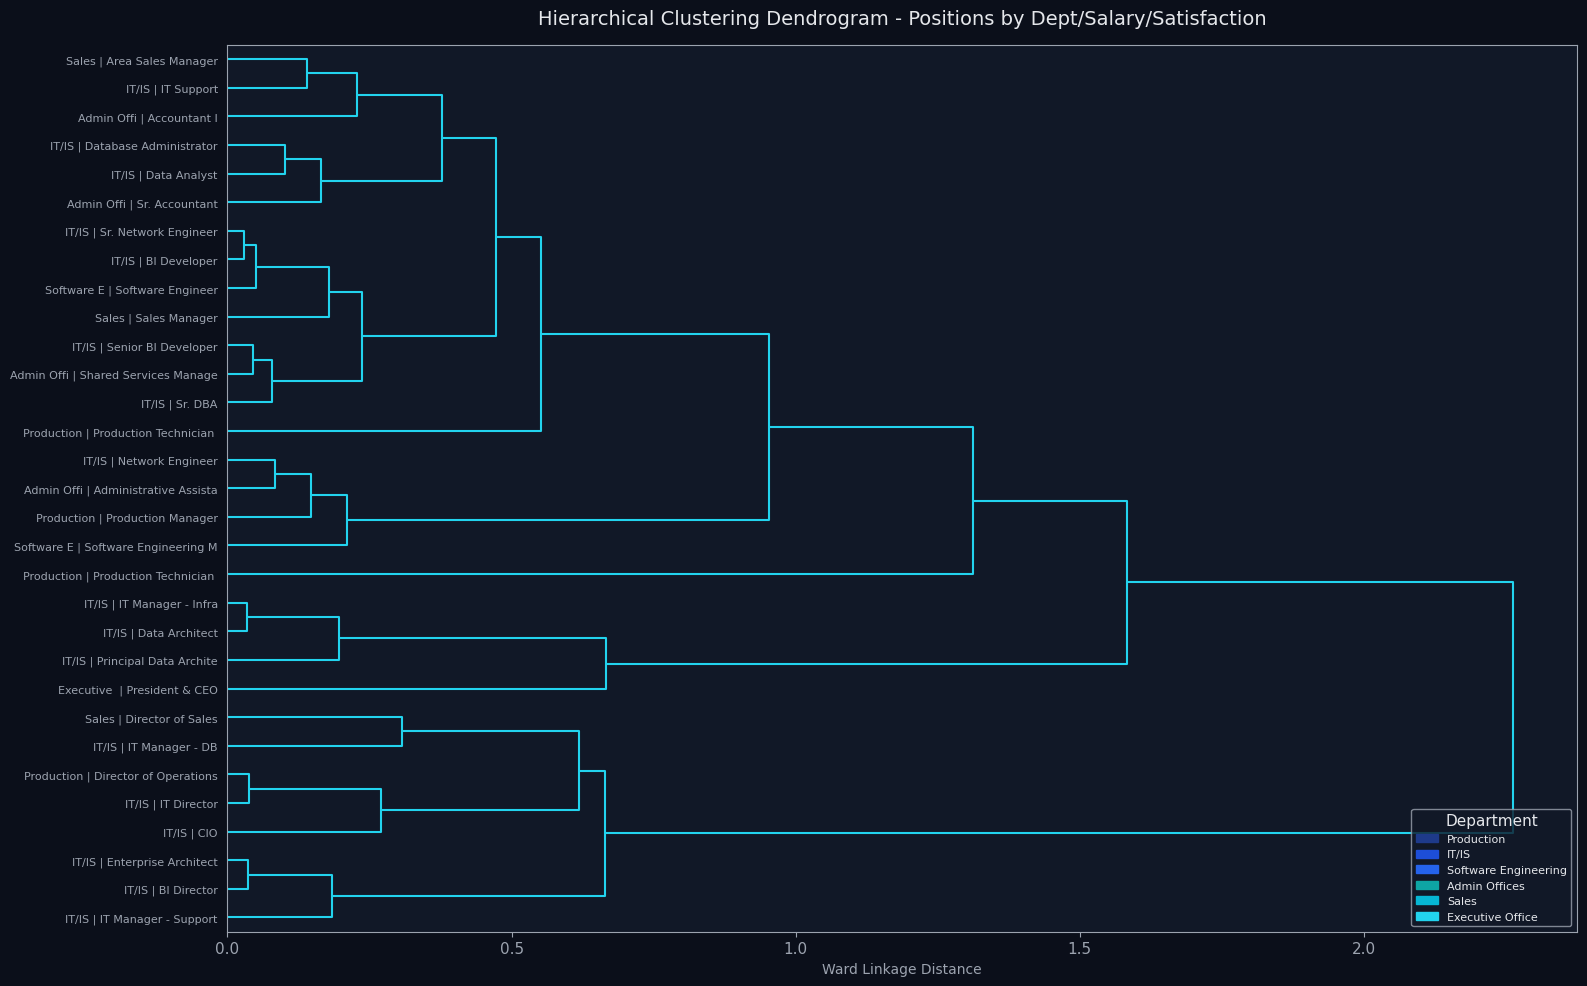

Dendrogram saved -> visualizations/dendrogram.png


In [5]:
dept_pos = (hr.groupby(['Department','Position'])
              .agg(Count=('Employee_Name','count'),
                   AvgSalary=('Salary','mean'),
                   AvgSat=('EmpSatisfaction','mean'))
              .reset_index())
dept_pos['label'] = dept_pos['Department'].str[:10] + ' | ' + dept_pos['Position'].str[:22]
X = dept_pos[['Count','AvgSalary','AvgSat']].fillna(0).values
X = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0) + 1e-9)
linked = sch.linkage(X, method='ward')
palette = ['#1E3A8A','#1D4ED8','#2563EB','#0EA5A4','#06B6D4','#22D3EE','#67E8F9','#A5F3FC']
dept_colors = {d: palette[i % len(palette)] for i, d in enumerate(hr['Department'].unique())}

fig, ax = plt.subplots(figsize=(16, 10))
fig.patch.set_facecolor(BG); ax.set_facecolor(SURFACE)
sch.dendrogram(linked, labels=dept_pos['label'].tolist(), orientation='right',
               leaf_font_size=7.5, color_threshold=0.45*max(linked[:,2]),
               link_color_func=lambda k: ACCENT, ax=ax)
for lbl in ax.get_yticklabels():
    txt = lbl.get_text(); dk = txt.split(' | ')[0].strip()
    matched = [d for d in dept_colors if d[:10].strip() == dk]
    lbl.set_color(dept_colors.get(matched[0], TEXT_PRI) if matched else TEXT_PRI)
    lbl.set_fontsize(8)
ax.set_title('Hierarchical Clustering Dendrogram - Positions by Dept/Salary/Satisfaction',
             color=TEXT_PRI, fontsize=14, pad=15)
ax.set_xlabel('Ward Linkage Distance', color=TEXT_SEC, fontsize=10)
ax.spines[['top','right','bottom','left']].set_color(TEXT_SEC)
ax.tick_params(colors=TEXT_SEC)
legend_patches = [mpatches.Patch(color=c, label=d) for d, c in dept_colors.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=8, title='Department',
          facecolor=SURFACE, edgecolor=TEXT_SEC, labelcolor=TEXT_PRI)
plt.tight_layout()
plt.savefig('visualizations/dendrogram.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Dendrogram saved -> visualizations/dendrogram.png')

---
## Dataset 2: OpenFlights Routes Dataset (routes.csv)

**Subset used:** First 600 rows for performance  
**Graph type:** Directed — nodes = airports (IATA codes), edges = airline routes  

| Column | Meaning |
|---|---|
| `src` | Source airport IATA code |
| `dst` | Destination airport IATA code |
| `airline` | Operating airline |
| `stops` | Number of stops (0 = non-stop) |

In [6]:
routes_raw = pd.read_csv('routes.csv', header=0)
routes_raw.columns = ['airline','airline_id','src','src_id','dst','dst_id',
                      'codeshare','stops','equipment']
routes_raw = routes_raw[routes_raw['src'].notna() & routes_raw['dst'].notna()]
routes_raw = routes_raw[routes_raw['src'].str.strip().str.len() == 3]
routes_raw = routes_raw[routes_raw['dst'].str.strip().str.len() == 3]
routes = routes_raw.head(600).copy()
print('Routes subset:', len(routes))

G = nx.DiGraph()
for _, row in routes.iterrows():
    G.add_edge(row['src'].strip(), row['dst'].strip(), airline=row['airline'])

deg     = dict(G.degree())
in_deg  = dict(G.in_degree())
out_deg = dict(G.out_degree())
top10   = sorted(deg.items(), key=lambda x: x[1], reverse=True)[:10]
node_list = list(G.nodes())

print('Nodes (airports):', G.number_of_nodes())
print('Edges (routes):  ', G.number_of_edges())
print('Top 10 hubs:', [(a, d) for a, d in top10])

Routes subset: 600
Nodes (airports): 265
Edges (routes):   598
Top 10 hubs: [('MNL', 38), ('SIN', 32), ('DME', 26), ('ARN', 26), ('CMN', 22), ('ZRH', 20), ('FLL', 20), ('IKT', 16), ('OUA', 16), ('DKR', 16)]


---
## Graph Visualization 1 - Spring (Force-Directed) Layout

**Algorithm:** Fruchterman-Reingold (k=1.8, 80 iterations)  
**Encoding:** Node size = total degree | Node colour = in-degree | Arrows = route direction  
Hub airports naturally migrate to the centre under repulsion/attraction forces.

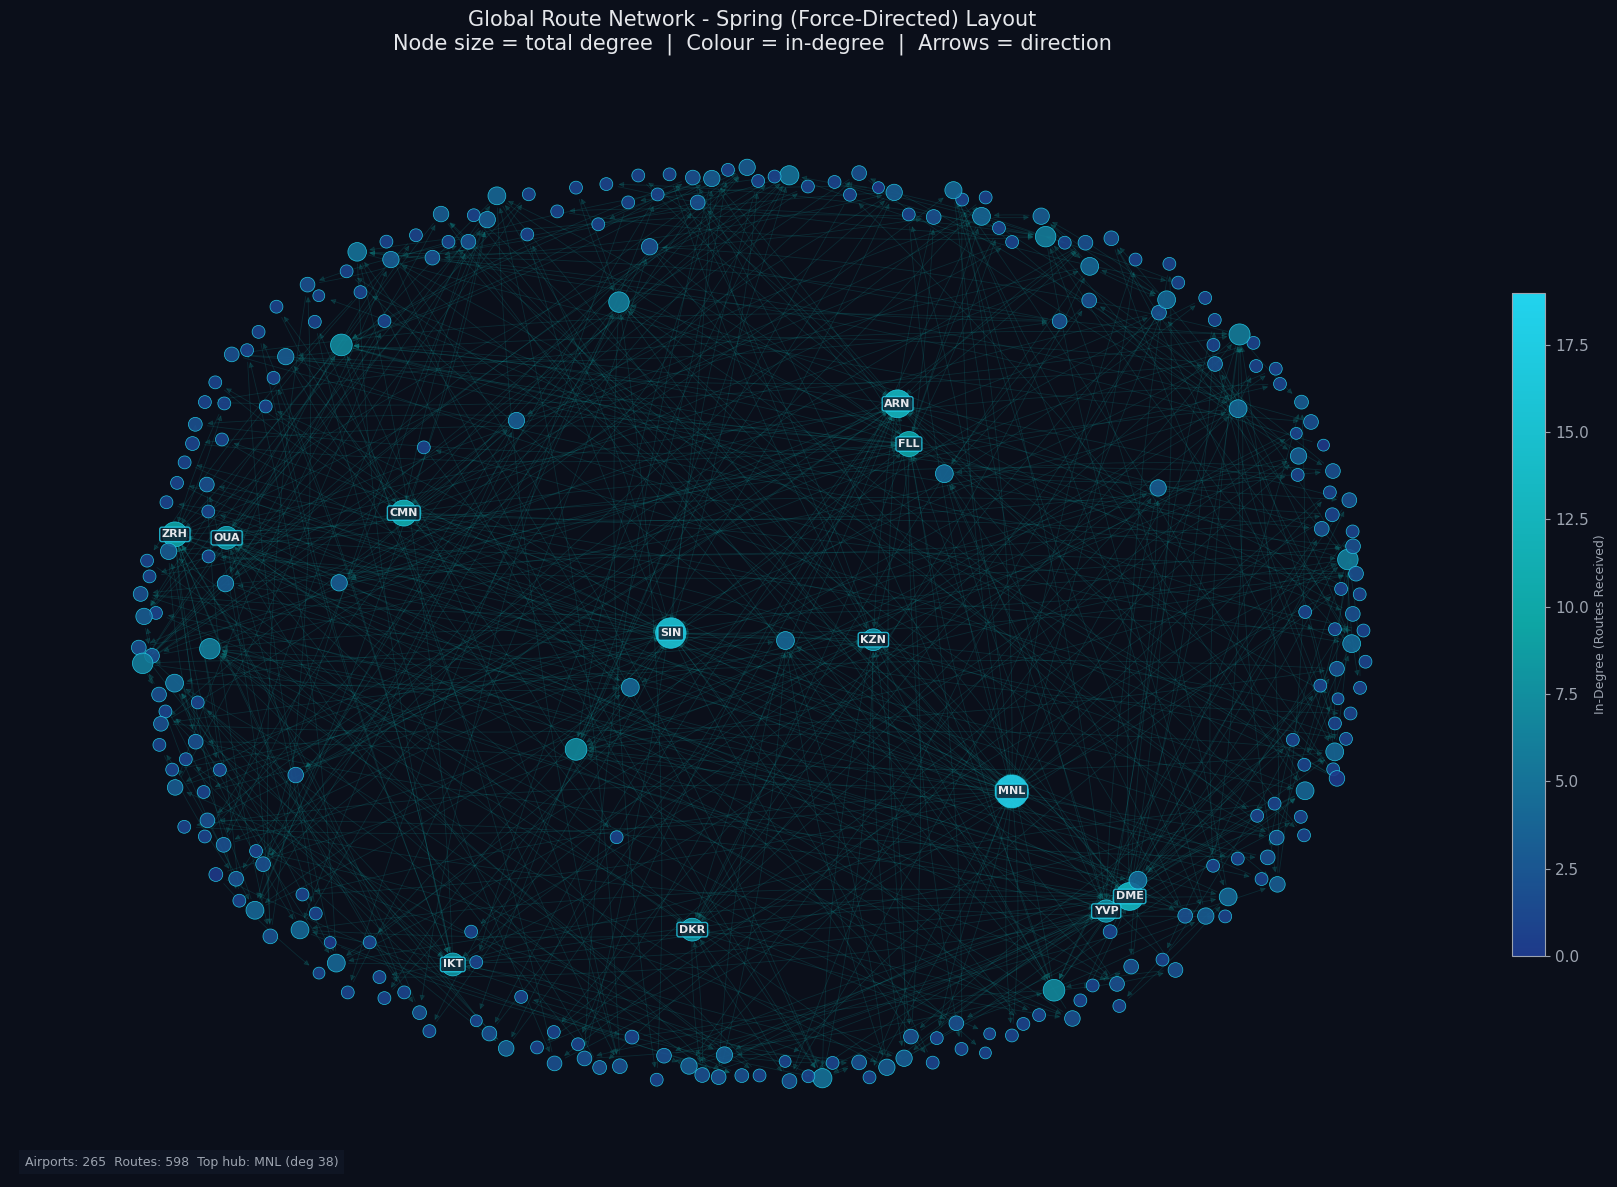

Spring layout saved -> visualizations/graph_spring.png


In [7]:
np.random.seed(42)
cmap = mcolors.LinearSegmentedColormap.from_list(
    'blue_teal', [PRIMARY, SECONDARY, ACCENT])
pos_spring = nx.spring_layout(G, k=1.8, iterations=80, seed=42)

degrees  = np.array([deg[n] for n in node_list])
in_degs  = np.array([in_deg[n] for n in node_list])
node_sizes  = 60 + (degrees / degrees.max()) * 500
norm        = mcolors.Normalize(vmin=in_degs.min(), vmax=in_degs.max())
node_colors = [cmap(norm(v)) for v in in_degs]

fig, ax = plt.subplots(figsize=(18, 12))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

nx.draw_networkx_edges(G, pos_spring, ax=ax,
    edge_color=SECONDARY, alpha=0.18, width=0.6,
    arrows=True, arrowstyle='-|>', arrowsize=8,
    connectionstyle='arc3,rad=0.05')
nx.draw_networkx_nodes(G, pos_spring, ax=ax,
    nodelist=node_list, node_size=node_sizes,
    node_color=node_colors, alpha=0.9,
    linewidths=0.5, edgecolors=ACCENT)

top12 = sorted(deg.items(), key=lambda x: x[1], reverse=True)[:12]
top12_nodes = {n: pos_spring[n] for n, _ in top12}
nx.draw_networkx_labels(G, top12_nodes, ax=ax,
    labels={n: n for n in top12_nodes},
    font_size=8, font_color=TEXT_PRI, font_weight='bold',
    bbox=dict(boxstyle='round,pad=0.2', facecolor=SURFACE, edgecolor=ACCENT, alpha=0.8))

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.01)
cbar.set_label('In-Degree (Routes Received)', color=TEXT_SEC, fontsize=9)
cbar.ax.yaxis.set_tick_params(color=TEXT_SEC)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=TEXT_SEC)
cbar.outline.set_edgecolor(TEXT_SEC)

ax.set_title(
    'Global Route Network - Spring (Force-Directed) Layout\n'
    'Node size = total degree  |  Colour = in-degree  |  Arrows = direction',
    color=TEXT_PRI, fontsize=15, pad=16)
ax.axis('off')
ax.text(0.01, 0.01,
    'Airports: {}  Routes: {}  Top hub: {} (deg {})'.format(
        G.number_of_nodes(), G.number_of_edges(), top10[0][0], top10[0][1]),
    transform=ax.transAxes, color=TEXT_SEC, fontsize=9,
    bbox=dict(facecolor=SURFACE, edgecolor='none', alpha=0.7))
plt.tight_layout()
plt.savefig('visualizations/graph_spring.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Spring layout saved -> visualizations/graph_spring.png')

---
## Graph Visualization 2 - Circular (Shell) Layout

**Layout:** Shell — 3 concentric rings sorted by degree tier  
- **Inner ring:** Top hub airports (highest degree)
- **Middle ring:** Mid-tier connectors
- **Outer ring:** Peripheral airports

Reveals hub-and-spoke topology clearly without the non-determinism of spring layout.

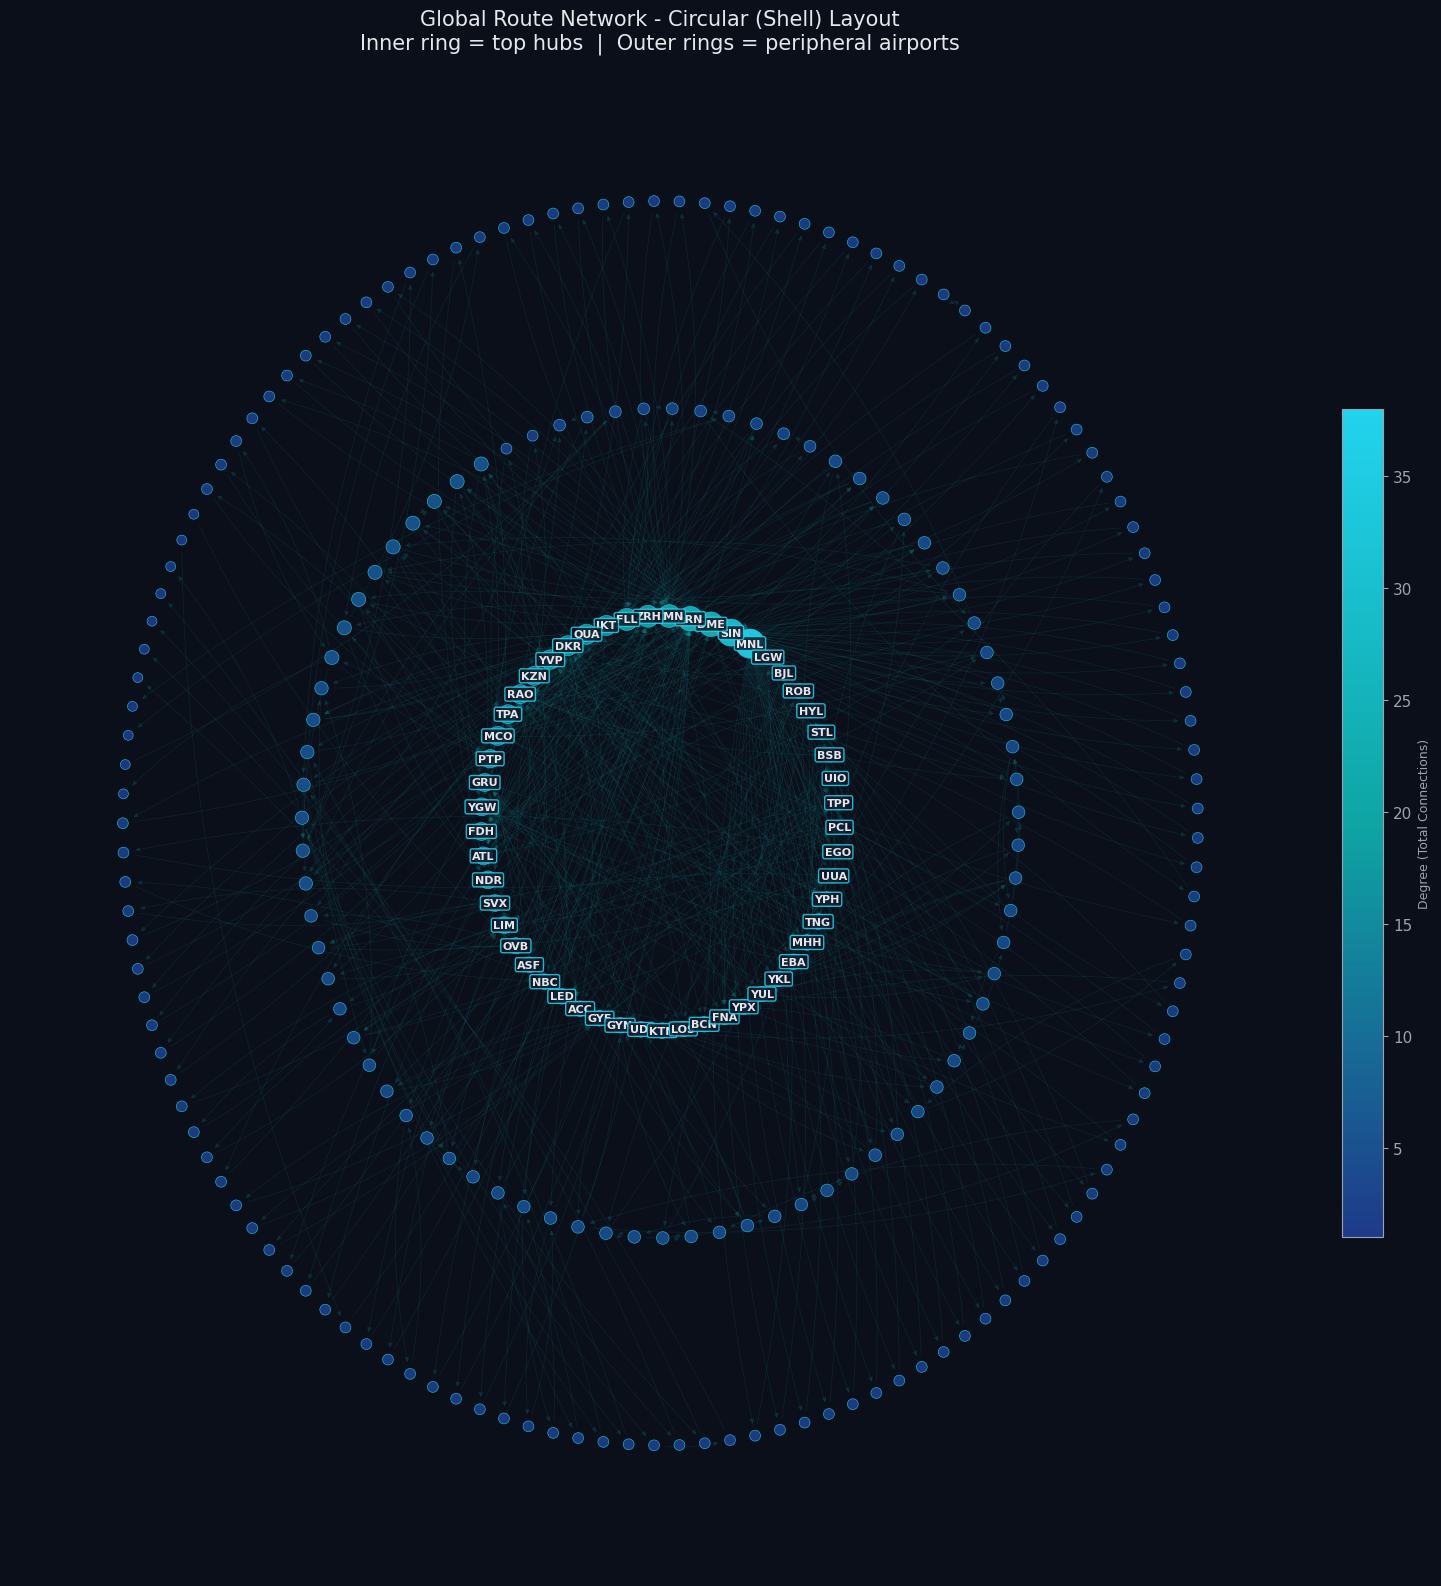

Circular layout saved -> visualizations/graph_circular.png


In [8]:
sorted_nodes = sorted(deg.items(), key=lambda x: x[1], reverse=True)
n_nodes = len(sorted_nodes)
tier1 = [nd for nd, _ in sorted_nodes[:max(1, n_nodes//5)]]
tier2 = [nd for nd, _ in sorted_nodes[n_nodes//5: n_nodes//2]]
tier3 = [nd for nd, _ in sorted_nodes[n_nodes//2:]]
pos_circ = nx.shell_layout(G, nlist=[tier1, tier2, tier3])

circ_deg    = np.array([deg[nd] for nd in node_list])
circ_norm   = mcolors.Normalize(vmin=circ_deg.min(), vmax=circ_deg.max())
circ_colors = [cmap(circ_norm(v)) for v in circ_deg]
circ_sizes  = 40 + (circ_deg / circ_deg.max()) * 400

fig, ax = plt.subplots(figsize=(16, 16))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

nx.draw_networkx_edges(G, pos_circ, ax=ax,
    edge_color=SECONDARY, alpha=0.14, width=0.5,
    arrows=True, arrowstyle='-|>', arrowsize=7,
    connectionstyle='arc3,rad=0.1')
nx.draw_networkx_nodes(G, pos_circ, ax=ax,
    nodelist=node_list, node_size=circ_sizes,
    node_color=circ_colors, alpha=0.92,
    linewidths=0.4, edgecolors=ACCENT)
nx.draw_networkx_labels(G, pos_circ, ax=ax,
    labels={nd: nd for nd in tier1},
    font_size=8, font_color=TEXT_PRI, font_weight='bold',
    bbox=dict(boxstyle='round,pad=0.18', facecolor=SURFACE, edgecolor=ACCENT, alpha=0.85))

ax.set_title(
    'Global Route Network - Circular (Shell) Layout\n'
    'Inner ring = top hubs  |  Outer rings = peripheral airports',
    color=TEXT_PRI, fontsize=15, pad=16)
ax.axis('off')
sm2 = plt.cm.ScalarMappable(cmap=cmap, norm=circ_norm); sm2.set_array([])
cbar2 = plt.colorbar(sm2, ax=ax, shrink=0.55, pad=0.02)
cbar2.set_label('Degree (Total Connections)', color=TEXT_SEC, fontsize=9)
cbar2.ax.yaxis.set_tick_params(color=TEXT_SEC)
plt.setp(cbar2.ax.yaxis.get_ticklabels(), color=TEXT_SEC)
cbar2.outline.set_edgecolor(TEXT_SEC)
plt.tight_layout()
plt.savefig('visualizations/graph_circular.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Circular layout saved -> visualizations/graph_circular.png')

---
## Comparison: Tree vs. Graph Insights

### Structural Analysis

| Dimension | Tree (HR Hierarchy) | Graph (Route Network) |
|---|---|---|
| Structure type | Strict DAG, single root | General directed graph (cyclic) |
| Depth | 4 levels | Flat - airports are peers |
| Branching | Production dept ~60% of nodes | Hub-and-spoke - few airports dominate |
| Density | Low (tree property) | Moderate - hubs are densely connected |
| Key insight | Production largest dept; IT/IS highest salary | Few hubs connect the entire network |

### Visual Technique Comparison

| Technique | Strength | Weakness |
|---|---|---|
| Treemap | Area differences instantly legible | Deep nesting loses context |
| Dendrogram | Reveals position similarity clusters | Hard to read at scale |
| Spring Layout | Natural hub emergence to centre | Non-deterministic positions |
| Circular Layout | Tier structure clear at a glance | Edge crossings can clutter |

### Key Findings
1. **Production dominates** (~60% headcount) but IT/IS commands the highest average salary.
2. **The route network is scale-free** - power-law degree distribution (Barabasi-Albert behaviour).
3. Both structures show **hierarchical inequality** - a few nodes carry disproportionate weight.

---
## Conclusion

This notebook explored the theme **'Organizational Structure & Global Connectivity'**:

**HR Dataset:**
- Treemap revealed *Production* employs the most; *Executive Office* commands highest salary.
- Dendrogram showed IT/IS positions cluster tightly (similar salary + satisfaction),
  suggesting a cohesive subculture distinct from the variable Production cluster.

**Routes Dataset:**
- Spring layout naturally surfaced hub airports at the force-directed centre.
- Circular layout confirmed a clear 3-tier structure: dominant hubs, mid-connectors, peripheral airports.

**Methodological Reflection:**
Trees represent containment hierarchies ideally; graphs capture peer-to-peer networks.
Both benefit from layered or interactive rendering to manage large node counts without clutter.

---
*Assignment 4 - Data Visualization | Dark Monochromatic Theme | April 2026*